# Applied Exercise 4 - SVM with Non-Linear Boundaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
rng = np.random.default_rng(1)
n = 100
X = rng.normal(size=(n, 2))
radius = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
y = (radius > 0.9).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print("=" * 60)
print("SIMULATED DATA")
print("=" * 60)
print(f"Observations: {n}")
print(f"Features: 2")
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

SIMULATED DATA
Observations: 100
Features: 2
Training observations: 70
Test observations: 30


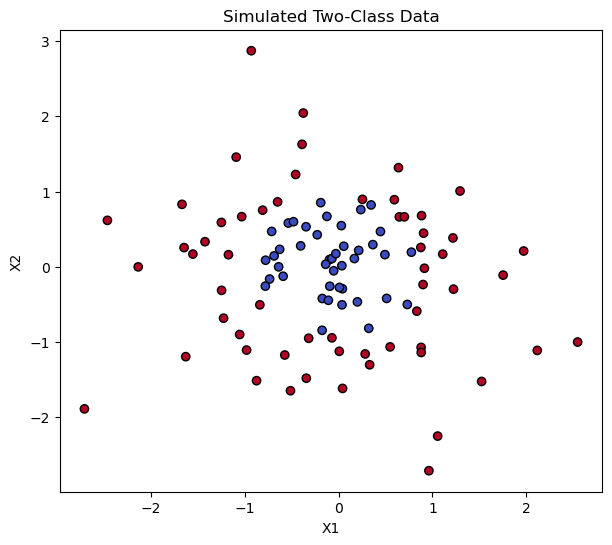

In [3]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulated Two-Class Data")
plt.show()

In [4]:
models = {"Support Vector Classifier": SVC(kernel="linear", C=1), "Polynomial SVM": SVC(kernel="poly", degree=2, C=1),
          "Radial SVM": SVC(kernel="rbf", C=1, gamma="scale")}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_error = 1 - accuracy_score(y_train, model.predict(X_train))
    test_error = 1 - accuracy_score(y_test, model.predict(X_test))
    results.append([name, train_error, test_error])

results = pd.DataFrame(results, columns=["Model", "Training Error", "Test Error"])

print("=" * 60)
print("SVM PERFORMANCE")
print("=" * 60)
print(results.to_string(index=False))

SVM PERFORMANCE
                    Model  Training Error  Test Error
Support Vector Classifier        0.414286    0.433333
           Polynomial SVM        0.014286    0.066667
               Radial SVM        0.057143    0.066667


The polynomial SVM and radial SVM are able to produce non-linear decision boundaries. Consequently, they achieve substantially lower training error than the linear support vector classifier. The test error provides a better measure of predictive performance because it evaluates the models on observations that were not used during training. In this case both Polynomial SVM of degree 2 and Radial kernel give same test errors and much better than Support Vector Classifier.

# Applied Exercise 5 - Logistic Regression vs SVM with Non-Linear Boundaries

In [5]:
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = (x1**2 - x2**2 > 0).astype(int)

X = pd.DataFrame({"X1": x1, "X2": x2})

print("=" * 60)
print("SIMULATED DATA")
print("=" * 60)
print(f"Observations: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Class 0 observations: {(y == 0).sum()}")
print(f"Class 1 observations: {(y == 1).sum()}")

SIMULATED DATA
Observations: 500
Features: 2
Class 0 observations: 247
Class 1 observations: 253


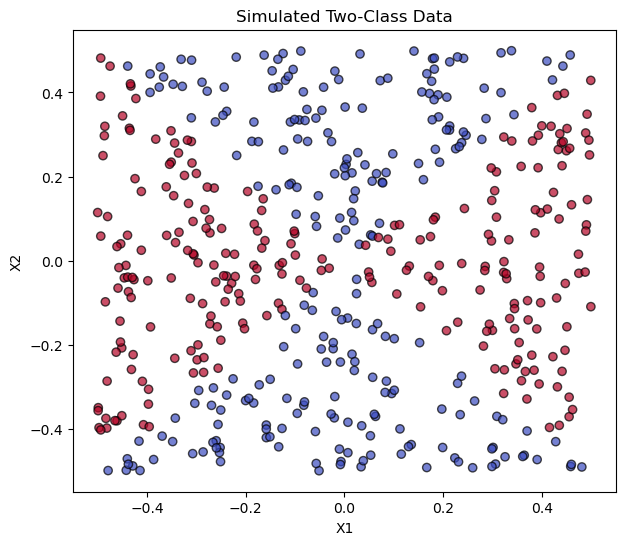

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulated Two-Class Data")
plt.show()

In [7]:
logistic_linear = LogisticRegression(C=1e6, max_iter=10000)
logistic_linear.fit(X, y)
y_pred_linear = logistic_linear.predict(X)

print("=" * 60)
print("LOGISTIC REGRESSION - LINEAR FEATURES")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_linear):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_linear):.4f}")

LOGISTIC REGRESSION - LINEAR FEATURES
Training accuracy = 0.4280
Training error = 0.5720


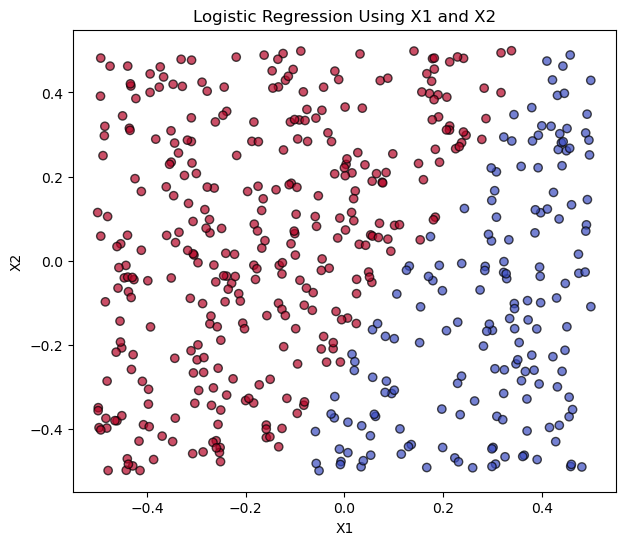

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_linear, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Logistic Regression Using X1 and X2")
plt.show()

In [9]:
X_nonlinear = pd.DataFrame({"X1": x1, "X2": x2, "X1_squared": x1**2, "X2_squared": x2**2, "X1_X2": x1*x2})

logistic_nonlinear = LogisticRegression(C=1e6, max_iter=10000)
logistic_nonlinear.fit(X_nonlinear, y)
y_pred_nonlinear = logistic_nonlinear.predict(X_nonlinear)

print("=" * 60)
print("LOGISTIC REGRESSION - NONLINEAR FEATURES")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_nonlinear):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_nonlinear):.4f}")

LOGISTIC REGRESSION - NONLINEAR FEATURES
Training accuracy = 1.0000
Training error = 0.0000


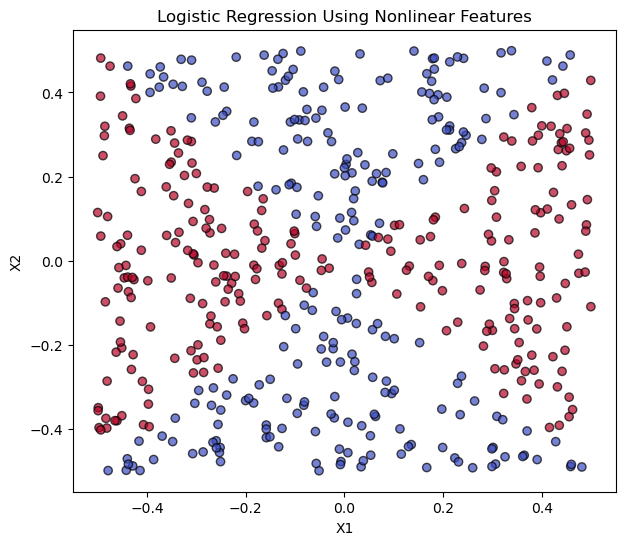

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_nonlinear, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Logistic Regression Using Nonlinear Features")
plt.show()

In [11]:
svc_linear = SVC(kernel="linear", C=1)
svc_linear.fit(X, y)
y_pred_svc = svc_linear.predict(X)

print("=" * 60)
print("SUPPORT VECTOR CLASSIFIER")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_svc):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_svc):.4f}")

SUPPORT VECTOR CLASSIFIER
Training accuracy = 0.5060
Training error = 0.4940


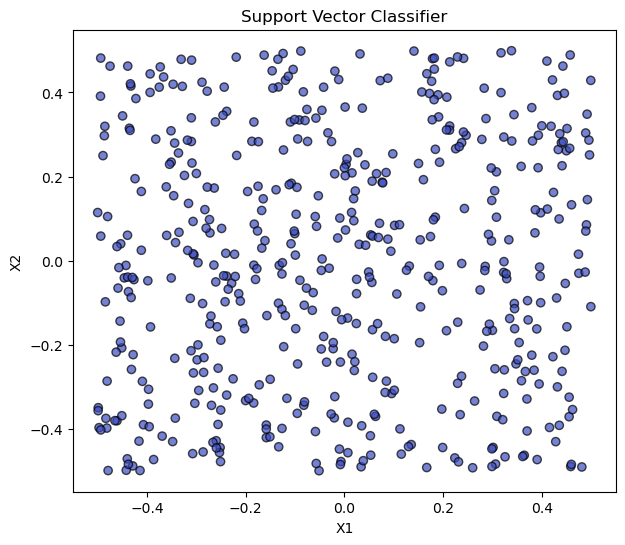

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_svc, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Support Vector Classifier")
plt.show()

In [13]:
svc_rbf = SVC(kernel="rbf", C=1, gamma="scale")
svc_rbf.fit(X, y)
y_pred_rbf = svc_rbf.predict(X)

print("=" * 60)
print("NONLINEAR SVM - RBF (Radial Basis Function) KERNEL")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_rbf):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_rbf):.4f}")

NONLINEAR SVM - RBF (Radial Basis Function) KERNEL
Training accuracy = 0.9860
Training error = 0.0140


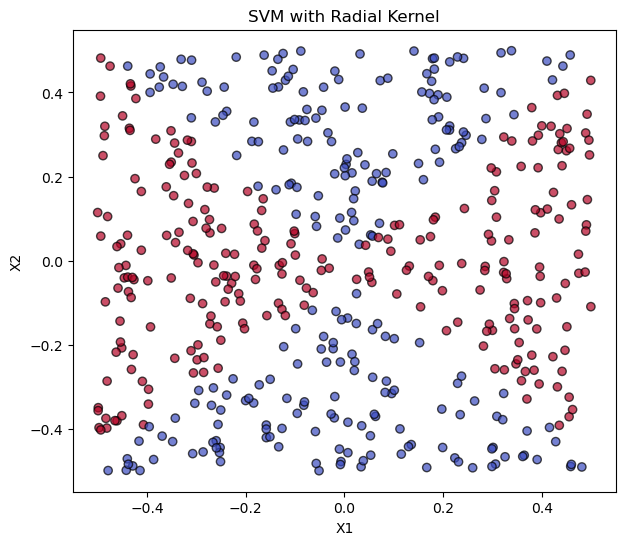

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_rbf, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM with Radial Kernel")
plt.show()

- Logistic regression using only X1 and X2 produces a linear decision boundary and therefore cannot capture the structure of the data particularly well and has igh training error of 57.2%
- When nonlinear transformations such as X1^2, X2^2, and X1X2 are added as predictors, logistic regression is able to produce a nonlinear decision boundary. The model remains linear in its coefficients, but it is nonlinear in the original predictors. This model execeedingly performs well with 100% accuracy because the original data was generated with very close predictor combinations.
- The linear support vector classifier has the same fundamental limitation because its decision boundary is linear. It has 49.4% training error and it simply classifies all the observations as one class and achieves more than 50% accuracy as slightly more than half of data points belong to one class.
- In contrast, the SVM using a radial kernel can construct a flexible nonlinear decision boundary and is therefore much better suited to this data. It performs well and has 1.4% training error. The reason that SVM has a tiny error rate comapred to Logistic regression is because SVM does few approximations for creating the radial kernel and may have slight misclassifications while logistic has a given a perfect boundary.

# Applied Exercise 6 - Support Vector Classifier and the Choice of `C`

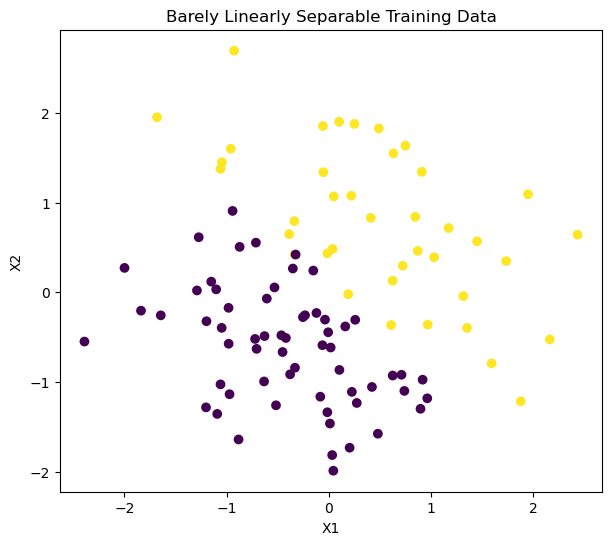

In [15]:
rng = np.random.default_rng(5)
n_train = 100
n_test = 1000

X_train = rng.normal(size=(n_train, 2))
y_train = (X_train[:, 0] + X_train[:, 1] > 0.15).astype(int)
X_train[:4] += rng.normal(scale=0.15, size=(4, 2))

X_test = rng.normal(size=(n_test, 2))
y_test = (X_test[:, 0] + X_test[:, 1] > 0.15).astype(int)

plt.figure(figsize=(7, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Barely Linearly Separable Training Data")
plt.show()

In [16]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
results = []

for C in C_values:
    model = SVC(kernel="linear", C=C)
    model.fit(X_train, y_train)
    train_error = np.mean(model.predict(X_train) != y_train)
    cv_error = 1 - cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy").mean()
    results.append([C, train_error, int(train_error * n_train), cv_error])

results = pd.DataFrame(results, columns=["C", "Training_Error", "Training_Misclassified", "CV_Error"])

print("=" * 60)
print("SUPPORT VECTOR CLASSIFIER — EFFECT OF C")
print("=" * 60)
print(results.to_string(index=False))

SUPPORT VECTOR CLASSIFIER — EFFECT OF C
        C  Training_Error  Training_Misclassified  CV_Error
    0.001            0.39                      39      0.39
    0.010            0.23                      23      0.27
    0.100            0.04                       4      0.04
    1.000            0.03                       3      0.03
   10.000            0.02                       2      0.03
  100.000            0.01                       1      0.03
 1000.000            0.01                       1      0.06
10000.000            0.01                       1      0.04


In [17]:
test_results = []
for C in C_values:
    model = SVC(kernel="linear", C=C)
    model.fit(X_train, y_train)
    train_error = np.mean(model.predict(X_train) != y_train)
    test_error = np.mean(model.predict(X_test) != y_test)
    test_results.append([C, train_error, test_error])

test_results = pd.DataFrame(test_results, columns=["C", "Training_Error", "Test_Error"])

print("=" * 60)
print("TRAINING VS TEST ERROR")
print("=" * 60)
print(test_results.to_string(index=False))

best_test_C = test_results.loc[test_results["Test_Error"].idxmin(), "C"]
best_cv_C = results.loc[results["CV_Error"].idxmin(), "C"]
best_train_C = test_results.loc[test_results["Training_Error"].idxmin(), "C"]

print("\nBest C based on training error =", best_train_C)
print("Best C based on CV error =", best_cv_C)
print("Best C based on test error =", best_test_C)

TRAINING VS TEST ERROR
        C  Training_Error  Test_Error
    0.001            0.39       0.500
    0.010            0.23       0.347
    0.100            0.04       0.073
    1.000            0.03       0.026
   10.000            0.02       0.017
  100.000            0.01       0.011
 1000.000            0.01       0.007
10000.000            0.01       0.005

Best C based on training error = 100.0
Best C based on CV error = 1.0
Best C based on test error = 10000.0


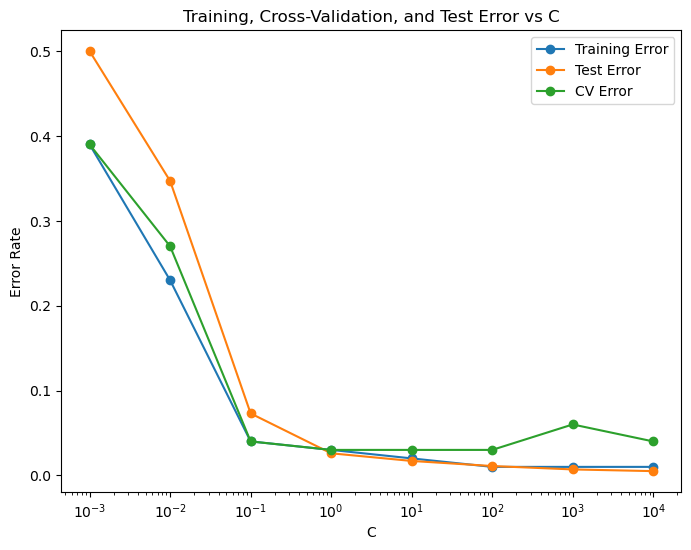

In [18]:
plt.figure(figsize=(8, 6))
plt.semilogx(test_results["C"], test_results["Training_Error"], marker="o", label="Training Error")
plt.semilogx(test_results["C"], test_results["Test_Error"], marker="o", label="Test Error")
plt.semilogx(results["C"], results["CV_Error"], marker="o", label="CV Error")
plt.xlabel("C")
plt.ylabel("Error Rate")
plt.title("Training, Cross-Validation, and Test Error vs C")
plt.legend()
plt.show()

- C can have 2 meanings. One is C can be considered as a budget constraint/tolerance level where small C -> less tolerance for misclassified observations and large C -> underfitting. THe other C can be considered as the penalty constraint (which sklearn uses) where small C -> less peanlty hence underfits and large C -> overfits as penalty for misclassification is high.
- The training error and CV error decreases for increase in C and starts to slightly icrease after a certain threshold of 1 or 100.
- The test error decreases with rise in C.
- In this data split, it means that the classes even though look barely linearly separable, in fact they were perfectly linearly separable and hence test error also decreases with increase in C.

# Applied Exercise 7 - SVM on the Auto Data Set

In [21]:
Auto = load_data("Auto").copy()
Auto["horsepower"] = pd.to_numeric(Auto["horsepower"], errors="coerce")
Auto = Auto.dropna().reset_index(drop=True)

median_mpg = Auto["mpg"].median()
Auto["high"] = (Auto["mpg"] > median_mpg).astype(int)

X = Auto.drop(columns=["mpg", "high"])
y = Auto["high"]

print("=" * 60)
print("BINARY RESPONSE")
print("=" * 60)
print(f"Median MPG = {median_mpg:.2f}")
print("\nClass counts:")
print(y.value_counts().sort_index())
print("\nPredictors:")
print(X.columns.tolist())

BINARY RESPONSE
Median MPG = 22.75

Class counts:
high
0    196
1    196
Name: count, dtype: int64

Predictors:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

linear_results = []
for C in C_values:
    model = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="linear", C=C))])
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    linear_results.append([C, 1 - scores.mean(), scores.std()])

linear_results = pd.DataFrame(linear_results, columns=["C", "CV_Error", "CV_SD"])

print("\n" + "=" * 60)
print("LINEAR SVC")
print("=" * 60)
print(linear_results.to_string(index=False))

best_linear_C = linear_results.loc[linear_results["CV_Error"].idxmin(), "C"]
print(f"\nBest C = {best_linear_C}")


LINEAR SVC
       C  CV_Error    CV_SD
   0.001  0.130315 0.050553
   0.010  0.089419 0.027203
   0.100  0.091951 0.031018
   1.000  0.102077 0.025761
  10.000  0.091821 0.009394
 100.000  0.089257 0.011189
1000.000  0.089257 0.011189

Best C = 100.0


In [23]:
radial_grid = {"svc__C": [0.01, 0.1, 1, 10, 100, 1000], "svc__gamma": ["scale", 0.001, 0.01, 0.1, 1]}
radial_pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf"))])
radial_search = GridSearchCV(radial_pipe, radial_grid, cv=cv, scoring="accuracy", n_jobs=-1)
radial_search.fit(X, y)

poly_grid = {"svc__C": [0.01, 0.1, 1, 10, 100], "svc__degree": [2, 3, 4, 5], "svc__gamma": ["scale", 0.001, 0.01, 0.1]}
poly_pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="poly"))])
poly_search = GridSearchCV(poly_pipe, poly_grid, cv=cv, scoring="accuracy", n_jobs=-1)
poly_search.fit(X, y)

print("\n" + "=" * 60)
print("RADIAL SVM")
print("=" * 60)
print(f"Best parameters: {radial_search.best_params_}")
print(f"Best CV error: {1 - radial_search.best_score_:.4f}")

print("\n" + "=" * 60)
print("POLYNOMIAL SVM")
print("=" * 60)
print(f"Best parameters: {poly_search.best_params_}")
print(f"Best CV error: {1 - poly_search.best_score_:.4f}")


RADIAL SVM
Best parameters: {'svc__C': 1, 'svc__gamma': 1}
Best CV error: 0.0767

POLYNOMIAL SVM
Best parameters: {'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'scale'}
Best CV error: 0.0766


In [24]:
comparison = pd.DataFrame({"Model": ["Linear SVC", "Radial SVM", "Polynomial SVM"],
                           "CV_Error": [linear_results["CV_Error"].min(), 1 - radial_search.best_score_, 1 - poly_search.best_score_]})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))


MODEL COMPARISON
         Model  CV_Error
    Linear SVC  0.089257
    Radial SVM  0.076696
Polynomial SVM  0.076566


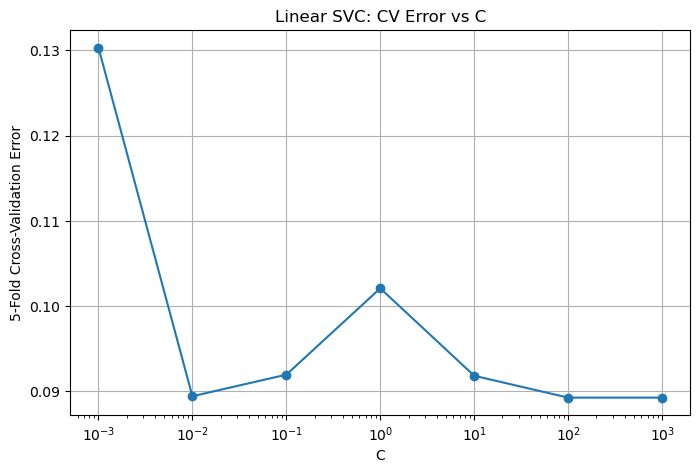

In [25]:
plt.figure(figsize=(8, 5))
plt.semilogx(linear_results["C"], linear_results["CV_Error"], marker="o")
plt.xlabel("C")
plt.ylabel("5-Fold Cross-Validation Error")
plt.title("Linear SVC: CV Error vs C")
plt.grid(True)
plt.show()

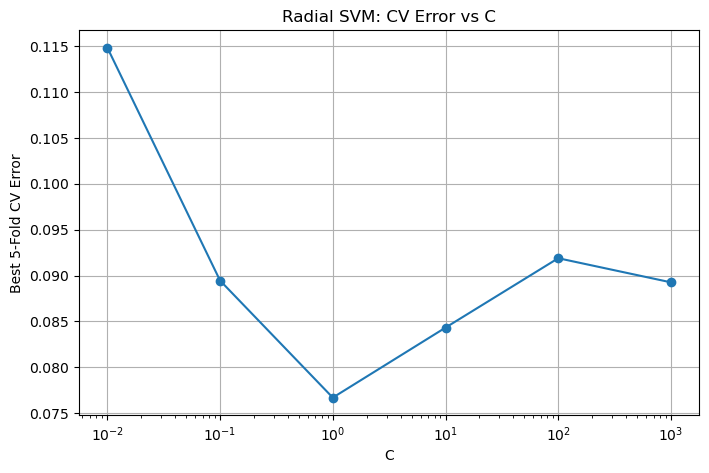

In [26]:
radial_results = pd.DataFrame(radial_search.cv_results_)
radial_plot = radial_results.groupby("param_svc__C")["mean_test_score"].max().reset_index()
radial_plot["C"] = radial_plot["param_svc__C"].astype(float)
radial_plot["CV_Error"] = 1 - radial_plot["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.semilogx(radial_plot["C"], radial_plot["CV_Error"], marker="o")
plt.xlabel("C")
plt.ylabel("Best 5-Fold CV Error")
plt.title("Radial SVM: CV Error vs C")
plt.grid(True)
plt.show()

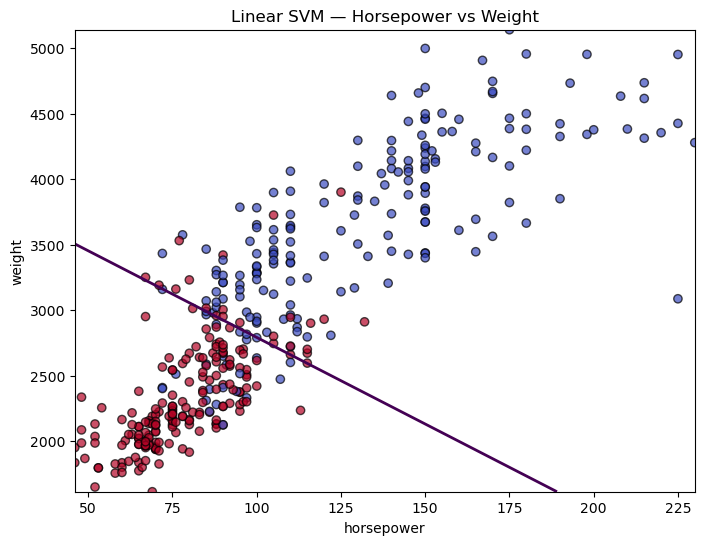

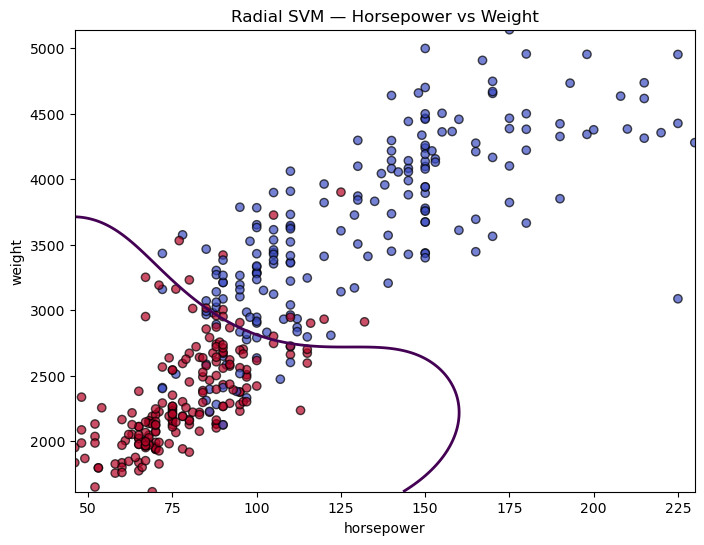

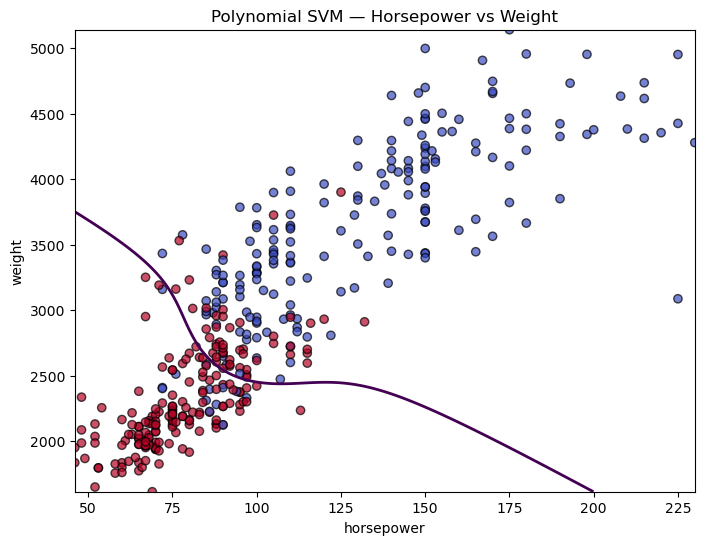

In [27]:
features = ["horsepower", "weight"]
X2 = Auto[features]
y2 = y

def plot_svm_boundary(model, X, y, title):
    model.fit(X, y)
    x0 = np.linspace(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 300)
    x1 = np.linspace(X.iloc[:, 1].min(), X.iloc[:, 1].max(), 300)
    xx, yy = np.meshgrid(x0, x1)
    grid = pd.DataFrame({X.columns[0]: xx.ravel(), X.columns[1]: yy.ravel()})
    zz = model.decision_function(grid).reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.7)
    plt.contour(xx, yy, zz, levels=[0], linewidths=2)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.show()

# Best linear model using two variables
linear_2d = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="linear", C=best_linear_C))])

# Best radial model using two variables
best_rbf_C = radial_search.best_params_["svc__C"]
best_rbf_gamma = radial_search.best_params_["svc__gamma"]
radial_2d = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", C=best_rbf_C, gamma=best_rbf_gamma))])

# Best polynomial model using two variables
best_poly_C = poly_search.best_params_["svc__C"]
best_poly_degree = poly_search.best_params_["svc__degree"]
best_poly_gamma = poly_search.best_params_["svc__gamma"]
poly_2d = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="poly", C=best_poly_C, degree=best_poly_degree, gamma=best_poly_gamma))])

plot_svm_boundary(linear_2d, X2, y2, "Linear SVM — Horsepower vs Weight")
plot_svm_boundary(radial_2d, X2, y2, "Radial SVM — Horsepower vs Weight")
plot_svm_boundary(poly_2d, X2, y2, "Polynomial SVM — Horsepower vs Weight")

- Support Vector Classifier uses a linear boundary to classify data points and perform poory on very low C(less penalty). As C increases, the penalty increases and it tries to overfit the data but the CV error hits hard lower bound at C=100.
- Radial and Polynomial SVM perform better using a non-linear curve and achieve very similar CV error results.
- Inferenece on CV error for this data split: Radial SVM ≈ Polynomial SVM < Linear SVC